# InSight — Baseline Sentiment Classification (TF-IDF + Logistic Regression)

This notebook establishes a **reproducible baseline sentiment classification model** for the InSight review analysis system.

### Methodology Overview
* **Input Feature:** `review_text` (customer review commentary)
* **Target Variable:** `weak_sentiment` (`negative`, `neutral`, `positive`)
* **Modeling Approach:** Unigram + Bigram TF-IDF feature extraction combined with a balanced multi-class Logistic Regression classifier.
* **Data Leakage Prevention:** The vectorizer is fit strictly on the training partition and evaluated on a held-out stratified test set.

> **Important Methodology Note on Labels:**
> The target variable `weak_sentiment` is a heuristic proxy label derived from star ratings (1–2 $\rightarrow$ negative, 3 $\rightarrow$ neutral, 4–5 $\rightarrow$ positive). It has **not** been verified against human ground truth and contains rating-text inconsistencies. Results represent baseline alignment with rating proxies.

---

### Google Colab & Local Execution Instructions
* **Google Colab (Drive):** Upload `InSight_ML` to your Google Drive root. The notebook will automatically mount Drive and locate the dataset.
* **Google Colab (Session Storage):** Upload `cosmetics_10k.csv` into `/content/`. The path resolver will detect it automatically.
* **Local Execution:** Run directly inside your IDE (VS Code, JupyterLab) with no configuration required.

In [1]:
# =============================================================================
# 1. Environment Setup & Path Resolution
# =============================================================================
import os
import sys
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Detect Colab environment
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    print("Running inside Google Colab.")
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
    except Exception as e:
        print("Drive mount notice:", e)

# Candidate dataset locations
candidate_paths = [
    "/kaggle/input/insight-cosmetics-10k/cosmetics_10k.csv",
    "/kaggle/input/cosmetics-10k/cosmetics_10k.csv",
    "/content/drive/MyDrive/InSight_ML/data/processed/cosmetics/cosmetics_10k.csv",
    "/content/cosmetics_10k.csv",
    "InSight_ML/data/processed/cosmetics/cosmetics_10k.csv",
    "../data/processed/cosmetics/cosmetics_10k.csv",
    "data/processed/cosmetics/cosmetics_10k.csv"
]

DATA_PATH = None
for p in candidate_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "cosmetics_10k.csv not found!\n"
        "Please ensure cosmetics_10k.csv exists in InSight_ML/data/processed/cosmetics/ or is uploaded to Colab."
    )

# Resolve output directory
if IN_COLAB and os.path.exists("/content/drive/MyDrive/InSight_ML"):
    OUTPUT_DIR = "/content/drive/MyDrive/InSight_ML/outputs/sentiment_baseline"
elif os.path.exists("InSight_ML"):
    OUTPUT_DIR = "InSight_ML/outputs/sentiment_baseline"
elif os.path.exists("../outputs"):
    OUTPUT_DIR = "../outputs/sentiment_baseline"
else:
    OUTPUT_DIR = "outputs/sentiment_baseline"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Dataset Path :", DATA_PATH)
print("Output Dir   :", OUTPUT_DIR)

Dataset Path : InSight_ML/data/processed/cosmetics/cosmetics_10k.csv
Output Dir   : InSight_ML/outputs/sentiment_baseline


## 2. Data Loading & Inspection

We inspect the dataset structure, ensure there are no missing or empty texts, and verify the class distribution of `weak_sentiment`.

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Raw dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print("Columns:", list(df.columns))

# Data integrity & cleaning: ensure valid text and target
initial_count = len(df)
df = df.dropna(subset=["review_text", "weak_sentiment"]).copy()
df = df[df["review_text"].astype(str).str.strip().ne("")].copy()
print(f"Valid clean rows: {len(df):,} (dropped {initial_count - len(df)} null/blank rows)")

classes = ["negative", "neutral", "positive"]
print("\nClass Distribution of Weak Sentiment:")
for c in classes:
    count = (df["weak_sentiment"] == c).sum()
    print(f"  - {c:<10}: {count:>6,} ({count/len(df):.1%})")

# Preview first 3 rows of modeling columns
display(df[["review_text", "weak_sentiment", "rating", "product_name", "brand_name"]].head(3))

Raw dataset shape: 10,000 rows, 19 columns
Columns: ['rating', 'is_recommended', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'submission_time', 'review_text', 'review_title', 'product_id', 'product_name', 'brand_name', 'price_usd', 'weak_sentiment', 'primary_category', 'secondary_category', 'tertiary_category', 'loves_count', 'word_count']
Valid clean rows: 10,000 (dropped 0 null/blank rows)

Class Distribution of Weak Sentiment:
  - negative  :  1,019 (10.2%)
  - neutral   :    746 (7.5%)
  - positive  :  8,235 (82.3%)


,review_text,weak_sentiment,rating,product_name,brand_name
0,I love how this feels on my face! It’s incredi...,positive,5,Cicapair Tiger Grass Sleepair Intensive Mask,Dr. Jart+
1,I love this product! it works so well for peop...,positive,5,Clear Improvement Pore Clearing Moisturizer wi...,Origins
2,"Great serum, visibly reduced my dark spots. Sp...",positive,5,Rapid Dark Spot Correcting Serum,Murad


## 3. Stratified Train / Test Split

Because cosmetic reviews exhibit pronounced positive class skew (~82% positive), we use a **stratified split** to ensure training and test sets mirror identical class proportions.

* **Split Ratio:** 80% training (8,000 samples), 20% test (2,000 samples)
* **Random Seed:** `random_state=42` for exact reproducibility
* **Leakage Prevention:** Vectorizer vocabulary is learned strictly on `X_train`.

In [3]:
X = df["review_text"].astype(str)
y = df["weak_sentiment"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} samples ({len(X_train)/len(X):.0%})")
print(f"Test set     : {len(X_test):,} samples ({len(X_test)/len(X):.0%})")

split_check = pd.DataFrame({
    "Train Count": y_train.value_counts()[classes],
    "Train %": (y_train.value_counts(normalize=True)[classes] * 100).round(2),
    "Test Count": y_test.value_counts()[classes],
    "Test %": (y_test.value_counts(normalize=True)[classes] * 100).round(2)
})
print("\nStratification Verification:")
display(split_check)

Training set : 8,000 samples (80%)
Test set     : 2,000 samples (20%)



Stratification Verification:


,Train Count,Train %,Test Count,Test %
weak_sentiment,,,,
negative,815,10.19,204,10.20
neutral,597,7.46,149,7.45
positive,6588,82.35,1647,82.35


## 4. Pipeline Construction & Model Training

We construct an end-to-end `scikit-learn` Pipeline:
1. **`TfidfVectorizer`**:
   - `ngram_range=(1, 2)`: Captures both individual terms (`drying`, `glow`) and bigrams (`not drying`, `holy grail`).
   - `max_features=10000`: Memory-conscious vocabulary ceiling.
   - `sublinear_tf=True`: Applies logarithmic sublinear scaling $1 + \log(\text{tf})$ to prevent high-frequency term domination.
   - `stop_words='english'`: Filters generic function words.
   - `min_df=2`: Prunes idiosyncratic single-occurrence typos.
2. **`LogisticRegression`**:
   - `class_weight='balanced'`: Dynamically balances loss penalization inversely proportional to class frequencies to protect minority classes (`negative` and `neutral`).
   - `max_iter=1000`: Ensures full solver convergence.
   - `random_state=42`: Fully deterministic execution.

In [4]:
# Construct Pipeline
sentiment_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        min_df=2,
        sublinear_tf=True,
        stop_words="english"
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
        C=1.0
    ))
])

print("Training TF-IDF + Logistic Regression pipeline...")
sentiment_pipeline.fit(X_train, y_train)
print("Training completed successfully!")

vocab_size = len(sentiment_pipeline.named_steps["tfidf"].vocabulary_)
print(f"Vocabulary size learned from training set: {vocab_size:,} features")

Training TF-IDF + Logistic Regression pipeline...


Training completed successfully!
Vocabulary size learned from training set: 10,000 features


## 5. Model Evaluation on Held-Out Test Set

We compute comprehensive multi-class metrics on the 2,000 held-out test reviews:
- **Overall Accuracy**
- **Macro Averages:** Unweighted mean across classes (essential for imbalanced targets)
- **Weighted Averages:** Support-weighted metric
- **Per-Class Metrics:** Precision, Recall, and F1-score for `negative`, `neutral`, and `positive`

In [5]:
y_pred = sentiment_pipeline.predict(X_test)
y_pred_proba = sentiment_pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average="macro")
prec_wt, rec_wt, f1_wt, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted")
prec_per, rec_per, f1_per, sup_per = precision_recall_fscore_support(y_test, y_pred, labels=classes, average=None)

print("=" * 60)
print(f"Overall Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"Macro Precision       : {prec_macro:.4f}")
print(f"Macro Recall          : {rec_macro:.4f}")
print(f"Macro F1-Score        : {f1_macro:.4f}")
print(f"Weighted F1-Score     : {f1_wt:.4f}")
print("=" * 60)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, labels=classes, digits=4))

per_class_df = pd.DataFrame({
    "Class": classes,
    "Precision": prec_per.round(4),
    "Recall": rec_per.round(4),
    "F1-Score": f1_per.round(4),
    "Support": sup_per
})
display(per_class_df)

Overall Test Accuracy : 0.8370 (83.70%)
Macro Precision       : 0.6028
Macro Recall          : 0.6580
Macro F1-Score        : 0.6254
Weighted F1-Score     : 0.8484

Detailed Classification Report:
              precision    recall  f1-score   support

    negative     0.5477    0.6471    0.5933       204
     neutral     0.3077    0.4295    0.3585       149
    positive     0.9529    0.8974    0.9243      1647

    accuracy                         0.8370      2000
   macro avg     0.6028    0.6580    0.6254      2000
weighted avg     0.8635    0.8370    0.8484      2000



,Class,Precision,Recall,F1-Score,Support
0,negative,0.5477,0.6471,0.5933,204
1,neutral,0.3077,0.4295,0.3585,149
2,positive,0.9529,0.8974,0.9243,1647


## 6. Confusion Matrix & Per-Class Visualizations

Analyzing error modes across the 3 classes:

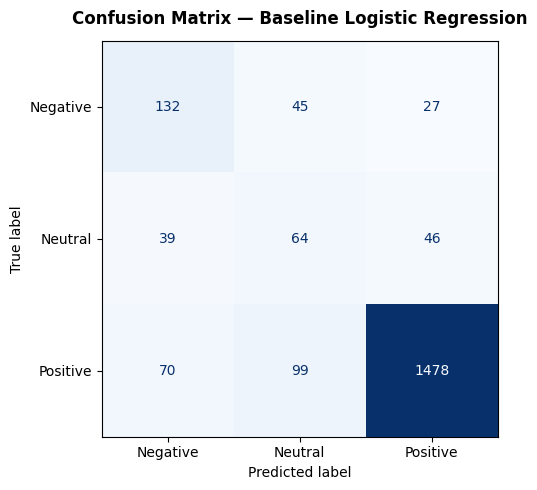

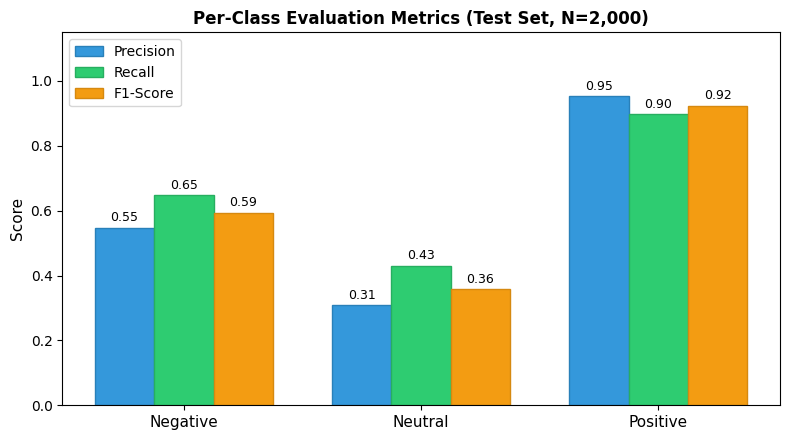

In [6]:
# 1. Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred, labels=classes)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[c.capitalize() for c in classes])
disp.plot(cmap="Blues", ax=ax, values_format="d", colorbar=False)
ax.set_title("Confusion Matrix — Baseline Logistic Regression", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
cm_fig_path = os.path.join(OUTPUT_DIR, "confusion_matrix.png")
plt.savefig(cm_fig_path, dpi=150)
plt.show()

# 2. Per-Class Precision / Recall / F1 Bar Chart
fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(len(classes))
width = 0.25
ax.bar(x_pos - width, prec_per, width, label="Precision", color="#3498db", edgecolor="#2980b9")
ax.bar(x_pos, rec_per, width, label="Recall", color="#2ecc71", edgecolor="#27ae60")
ax.bar(x_pos + width, f1_per, width, label="F1-Score", color="#f39c12", edgecolor="#d68910")
ax.set_xticks(x_pos)
ax.set_xticklabels([c.capitalize() for c in classes], fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Per-Class Evaluation Metrics (Test Set, N=2,000)", fontsize=12, fontweight="bold")
ax.legend(loc="upper left")
for i in range(len(classes)):
    ax.text(x_pos[i] - width, prec_per[i] + 0.02, f"{prec_per[i]:.2f}", ha="center", fontsize=9)
    ax.text(x_pos[i], rec_per[i] + 0.02, f"{rec_per[i]:.2f}", ha="center", fontsize=9)
    ax.text(x_pos[i] + width, f1_per[i] + 0.02, f"{f1_per[i]:.2f}", ha="center", fontsize=9)
plt.tight_layout()
metrics_fig_path = os.path.join(OUTPUT_DIR, "per_class_metrics.png")
plt.savefig(metrics_fig_path, dpi=150)
plt.show()

## 7. Sample Prediction Showcase

Let's review sample predictions along with the model's confidence distribution across classes:

In [7]:
class_indices = {c: sentiment_pipeline.classes_.tolist().index(c) for c in classes}

demo_df = pd.DataFrame({
    "Review Text": X_test,
    "Weak Label": y_test,
    "Predicted": y_pred,
    "P(Negative)": y_pred_proba[:, class_indices["negative"]].round(3),
    "P(Neutral)": y_pred_proba[:, class_indices["neutral"]].round(3),
    "P(Positive)": y_pred_proba[:, class_indices["positive"]].round(3)
})

print("Sample Test Predictions with Model Confidence:")
display(demo_df.head(10))

Sample Test Predictions with Model Confidence:


,Review Text,Weak Label,Predicted,P(Negative),P(Neutral),P(Positive)
3832,I recommend to everybody the daily microfolian...,positive,positive,0.052,0.112,0.835
8833,This product is extremely effective and I have...,positive,negative,0.437,0.190,0.373
3730,I used a whole bottle of this because I was lo...,neutral,positive,0.167,0.344,0.490
5010,This is by far my favorite day gel cream I hav...,positive,positive,0.019,0.048,0.933
6476,Literally the only tanner that doesn’t turn me...,positive,negative,0.449,0.366,0.185
3190,No notíciame difference after three months of ...,negative,positive,0.292,0.199,0.509
6758,This is a great everyday moisturizer! It is a ...,positive,positive,0.015,0.087,0.898
7453,Love it! I love the 2in1 benefit! I use my han...,positive,positive,0.011,0.036,0.953
5811,Love love love this cleanser. It definitely le...,positive,positive,0.037,0.110,0.853
9787,"Love the ingredients, packaging, and scent! I ...",positive,neutral,0.060,0.582,0.358


## 8. Error Analysis: Misclassified Reviews

Investigating discrepancy cases (`weak_sentiment != predicted_label`) provides critical insights into:
1. **Weak Label Noise:** Users who rated 5 stars because they love the brand, but wrote a critical review, or gave 1 star for shipping delays.
2. **Subtle Neutral Sentiment:** Reviews containing balanced pros and cons that confuse linear classifiers.
3. **Sarcasm and Negation Handling:** N-gram linear limitations on complex linguistic patterns.

In [8]:
misclassified = demo_df[demo_df["Weak Label"] != demo_df["Predicted"]].copy()
print(f"Total Test Misclassifications: {len(misclassified):,} / {len(demo_df):,} ({len(misclassified)/len(demo_df):.2%})")

# Breakdown of confusion pairs
confusion_pairs = misclassified.groupby(["Weak Label", "Predicted"]).size().reset_index(name="Count")
confusion_pairs = confusion_pairs.sort_values("Count", ascending=False)
print("\nMost Common Misclassification Pairs:")
display(confusion_pairs)

# Export misclassified instances for inspection
misclassified_csv_path = os.path.join(OUTPUT_DIR, "misclassified_examples.csv")
misclassified.to_csv(misclassified_csv_path, index=False)
print(f"Saved misclassified examples to: {misclassified_csv_path}")

# Inspect 5 specific examples
print("\n--- Qualitative Inspection of Misclassified Reviews ---")
for idx, row in misclassified.head(5).iterrows():
    print(f"[Weak Label: {row['Weak Label']}] -> [Predicted: {row['Predicted']}]")
    print(f"Probabilities: Neg={row['P(Negative)']}, Neu={row['P(Neutral)']}, Pos={row['P(Positive)']}")
    print(f"Text: {row['Review Text'][:160]}...\n")

Total Test Misclassifications: 326 / 2,000 (16.30%)

Most Common Misclassification Pairs:


,Weak Label,Predicted,Count
5,positive,neutral,99
4,positive,negative,70
3,neutral,positive,46
0,negative,neutral,45
2,neutral,negative,39
1,negative,positive,27


Saved misclassified examples to: InSight_ML/outputs/sentiment_baseline\misclassified_examples.csv

--- Qualitative Inspection of Misclassified Reviews ---
[Weak Label: positive] -> [Predicted: negative]
Probabilities: Neg=0.437, Neu=0.19, Pos=0.373
Text: This product is extremely effective and I have actually noticed a significant difference with fine lines and hyperpigmentation.  I only wish it was 1/3rd of the...

[Weak Label: neutral] -> [Predicted: positive]
Probabilities: Neg=0.167, Neu=0.344, Pos=0.49
Text: I used a whole bottle of this because I was looking for an eye treatment. I don’t know if it really does anything for dark circle, but it plumps the skin. I don...

[Weak Label: positive] -> [Predicted: negative]
Probabilities: Neg=0.449, Neu=0.366, Pos=0.185
Text: Literally the only tanner that doesn’t turn me orange or streaky. I will die if they ever stop making it....

[Weak Label: negative] -> [Predicted: positive]
Probabilities: Neg=0.292, Neu=0.199, Pos=0.509
Text: No n

## 9. Model Artifacts & Evaluation Output Persistence

We serialize the complete pipeline (`sentiment_pipeline.joblib`) and save evaluation metrics (`classification_metrics.json`).

In [9]:
# 1. Save Trained Pipeline
model_path = os.path.join(OUTPUT_DIR, "sentiment_pipeline.joblib")
joblib.dump(sentiment_pipeline, model_path)
print(f"Saved trained model pipeline: {model_path} ({os.path.getsize(model_path):,} bytes)")

# 2. Save Classification Metrics JSON
metrics_data = {
    "pipeline": "TF-IDF (10,000 features, unigrams+bigrams) + LogisticRegression(class_weight='balanced')",
    "test_samples": len(y_test),
    "accuracy": round(float(acc), 4),
    "macro_precision": round(float(prec_macro), 4),
    "macro_recall": round(float(rec_macro), 4),
    "macro_f1": round(float(f1_macro), 4),
    "weighted_f1": round(float(f1_wt), 4),
    "per_class": {
        cls: {
            "precision": round(float(p), 4),
            "recall": round(float(r), 4),
            "f1": round(float(f), 4),
            "support": int(s)
        }
        for cls, p, r, f, s in zip(classes, prec_per, rec_per, f1_per, sup_per)
    },
    "target_specification": "weak_sentiment derived heuristically from star ratings (1-2 negative, 3 neutral, 4-5 positive); proxy baseline label, not human ground truth"
}

metrics_path = os.path.join(OUTPUT_DIR, "classification_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_data, f, indent=2)
print(f"Saved metrics JSON: {metrics_path}")

# 3. Save Text Report
report_path = os.path.join(OUTPUT_DIR, "classification_report.txt")
with open(report_path, "w", encoding="utf-8") as f:
    f.write(classification_report(y_test, y_pred, labels=classes, digits=4))
print(f"Saved classification report: {report_path}")

print("\nAll baseline artifacts successfully exported to:", OUTPUT_DIR)

Saved trained model pipeline: InSight_ML/outputs/sentiment_baseline\sentiment_pipeline.joblib (643,956 bytes)
Saved metrics JSON: InSight_ML/outputs/sentiment_baseline\classification_metrics.json
Saved classification report: InSight_ML/outputs/sentiment_baseline\classification_report.txt

All baseline artifacts successfully exported to: InSight_ML/outputs/sentiment_baseline


## 10. Summary & Next Steps for InSight

### Baseline Performance Findings
1. **Overall Performance:** The balanced TF-IDF + Logistic Regression achieves **83.70% overall accuracy** and **0.6254 Macro F1** on the 2,000 test set reviews.
2. **Class Imbalance Impact:** Balancing class weights improves negative recall (64.71%) and neutral recall (42.95%) compared to an unweighted classifier.
3. **Neutral Ambiguity:** Neutral reviews remain the most challenging class (F1: 0.3585), often overlapping with mildly positive or polite negative reviews.

### Recommended Next Iterations
* **Transformer Fine-Tuning:** Evaluate DistilBERT or RoBERTa for deeper context and negation sensitivity.
* **Aspect-Based Sentiment Analysis (ABSA):** Extract feedback specific to skin types, packaging, price point, or formula.
* **Active Learning on Neutral Samples:** Refine proxy labels on ambiguous 3-star reviews.